References:

Analytical structural vulnerability and classification of Italian residential building stock to tsunami hazard
DOI 10.4430/bgo00398(2022)
    - gives vulnerability functions for residential, construction type ( masonary, reinforced concrete), for different ages, heights and design

Effect of buoyancy loads on the tsunami fragility of existing reinforced concrete frames including consideration of blow‑out slabs 
https://doi.org/10.1038/s41598-023-36237-7 (2023)
    - gives fragility functions for reinforced concrete buildings, of different frame heights, damage scenarios and damage states

A mechanics-based method towards risk assessment of RC buildings under tsunami and flow-type hazards
https://doi.org/10.1016/j.engstruct.2022.114452 (2022)
    - compares fragility function of those obtained by opensees and SAFETI method 

Preliminary tsunami analytical fragility functions proposal for Italian coastal residential masonry buildings
https://doi.org/10.1016/j.istruc.2021.01.059 (2021)
    - gives fragility functions for masonry buildings, of different heights, damage scenarios and damage states

Antoncecchi, I., Ciccone, F., Dialuce, G., Grandi, S., Terlizzeze, F.,
Di Bucci, D., Dolce, M., Argnani, A., Mercorella, A., Pellegrini,
C., Rovere, M., Armigliato, A., Pagnoni, G., Paparo, M. A., Tinti,
S., Zaniboni, F., Basili, R., Cavallaro, D., Coltelli, M., Firetto
Carlino, M., Lipparini, L., Lorito, S., Maesano, F. E., Romano,
F., Scarfì, L., Tiberti, M. M., Volpe, M., Fedorik, J., Toscani, G.,
Borzi, B., Faravelli, M., Bozzoni, F., Pascale, V., Quaroni, D.,
Germagnoli, F., Belliazzi, S., Del Zoppo, M., Di Ludovico, M.,
Lignola, G. P., and Prota, A.: Progetto SPOT – Sismicità Potenzialmente
Innescabile Offshore e Tsunami: Report integrato di
fine progetto, 1. Ministero dello Sviluppo Economico, Zenodo,
https://doi.org/10.5281/zenodo.3732887, 2020.
    - gives damage state and reconstruction cost modelling for Italy


Analytical structural vulnerability and classification of Italian residential building stock to tsunami hazard(DOI 10.4430/bgo00398)
- Plot Masonary gravity design for Age0 for testing purposes.

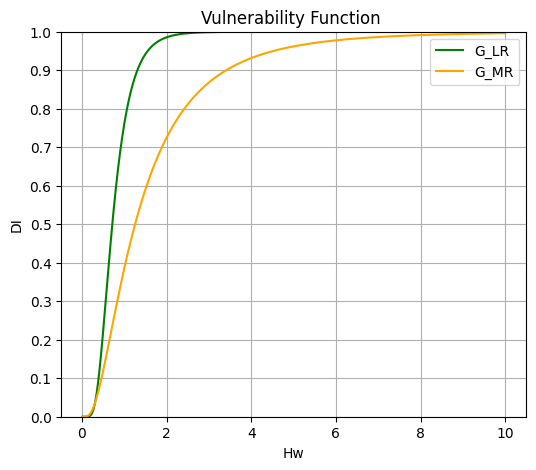

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Given parameters
mu = [0.8,1.7]  # mean
ln_sigma = [0.47,0.78]  # lognormal standard deviation
depth = np.linspace(0.01, 10, 1000)
col = ['g', 'orange', ]
names = ['G_LR', 'G_MR']
plt.figure(figsize=(6, 5))
for i in range(2):
    ln_mu = np.log(mu[i]) - 0.5 * ln_sigma[i] ** 2
    DI = lognorm.cdf(depth, s=ln_sigma[i], scale=np.exp(ln_mu))
    plt.plot(depth, DI, label=names[i], color=col[i])
plt.xlabel('Hw')
plt.ylabel('DI')
plt.title('Vulnerability Function ')
plt.legend()
plt.grid(True)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 11, 2))
plt.ylim([0, 1])
plt.show()



- Plot RC gravity and seismic design for Age1

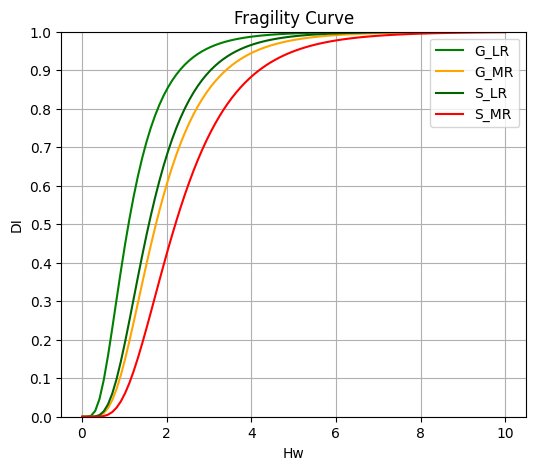

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Given parameters
mu = [1.3,2.0,1.8,2.5]  # mean
ln_sigma = [0.58,0.52,0.51,0.50]  # lognormal standard deviation
depth = np.linspace(0.01, 10, 100)
col = ['g', 'orange', 'darkgreen', 'red']
names = ['G_LR', 'G_MR', 'S_LR', 'S_MR']
plt.figure(figsize=(6, 5))
for i in range(4):
    ln_mu = np.log(mu[i]) - 0.5 * ln_sigma[i] ** 2
    DI = lognorm.cdf(depth, s=ln_sigma[i], scale=np.exp(ln_mu))
    plt.plot(depth, DI, label=names[i], color=col[i])
plt.xlabel('Hw')
plt.ylabel('DI')
plt.title('Fragility Curve')
plt.legend()
plt.grid(True)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 11, 2))
plt.ylim([0, 1])
plt.show()

Effect of buoyancy loads on the tsunami fragility of existing reinforced concrete frames including consideration of blow‑out slabs( https://doi.org/10.1038/s41598-023-36237-7)
- scenario(i) no uplift low rise


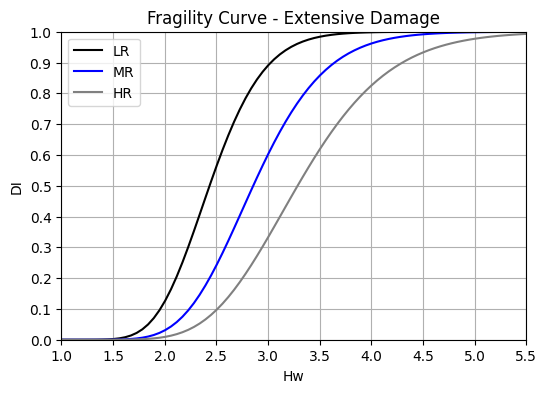

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Given parameters
median = [0.89,1.05,1.19]  # meadian
ln_sigma = [0.17,0.19,0.21]  # lognormal standard deviation
depth = np.linspace(0.01, 5.5, 100)
col = ['k', 'b', 'grey']
names = ['LR', 'MR', 'HR']
plt.figure(figsize=(6, 4))
for i in range(3):
    pd = lognorm.cdf(depth, s=ln_sigma[i], scale=np.exp(median[i]))
    plt.plot(depth, pd, label=names[i], color=col[i])
plt.xlabel('Hw')
plt.ylabel('DI')
plt.title('Fragility Curve - Extensive Damage')
plt.legend()
plt.grid(True)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 6, 0.5))
plt.ylim([0, 1])
plt.xlim([1, 5.5])
plt.show()

Mo's Code

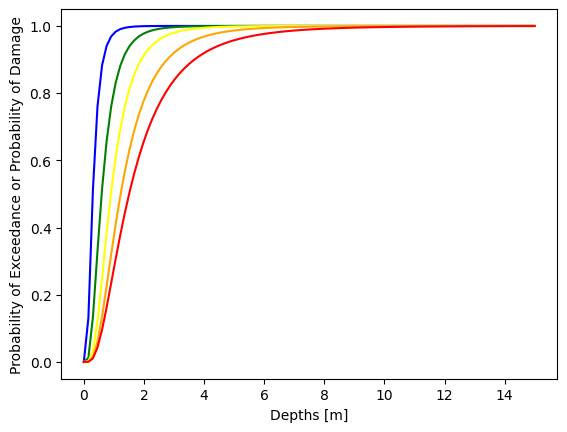

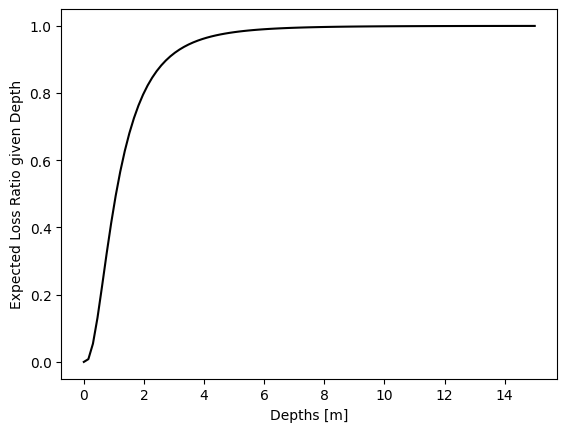

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Oct 15 14:14:30 2024

@author: mnafeh
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def calculate_tsunami_fragility(depths,theta,beta):
    """
    Calculate the fragility functions (i.e., CDFs) for a single damage state through a median seismic intensity and associated dispersion
    Parameters
    ----------
    theta:                        float                Median seismic intensity given edp-based damage threshold.
    beta:                         float                Total uncertainty (i.e. accounting for record-to-record and modelling variabilities).
    
    Returns
    -------
    INTENSITIES:                   list                List of intensity measure levels used to sample the fragility function
    p:                             list                Probability of exceedance of the sampled damage state
   
    """
    
    p = stats.lognorm.cdf(depths, s=beta, loc=0, scale=theta)

    return p

def calculate_tsunami_vulnerability(depths, damageStateProbability,consequenceModel):
    """
    Calculate the vulnerability function associated with a building class given the probabilities of exceedance and a consequence model

    Parameters
    ----------
    damageStateProbability:       array                Probabilities of exceedance associated with the damage states considered (size = Intensity measure levels x nDS)
    consequenceModel:              list                List of damage-to-loss ratios
    Returns
    -------
    vulnCurve:                    array                Vulnerability functions containing two columns, first is intensities (fixed range) and expected loss ratios (the uncertainty is modelled separately)
    """    
    
    ### Do some consistency checks
    if len(consequenceModel)!=np.size(damageStateProbability,1):
          raise Exception('Mismatch between the fragility consequence models!')
    if len(depths)!=np.size(damageStateProbability,0):
          raise Exception('Mismatch between the number of IMLs and fragility models!')
    
    lossArray=np.zeros([len(depths),1])
    for i in range(len(depths)):
          for j in range(0,np.size(damageStateProbability,1)):
                if j==(np.size(damageStateProbability,1)-1):
                      lossArray[i,0]=lossArray[i,0]+damageStateProbability[i,j]*consequenceModel[j]
                else:
                      lossArray[i,0]=lossArray[i,0]+(damageStateProbability[i,j]-damageStateProbability[i,j+1])*consequenceModel[j]
                          
    tmp=np.column_stack((depths,lossArray))
    vulnCurve=tmp[tmp[:,0].argsort()]
    
    return vulnCurve


### EXAMPLE

### define constants
mu = [-1.213, -0.522, -0.104, 0.203, 0.410]
sigma = [0.6, 0.605, 0.586, 0.637, 0.697]
DLR = [0.05, 0.15, 0.40, 0.65, 1.00]
depths = np.linspace(0.00, 15, 100)
colors = ['blue','green', 'yellow', 'orange', 'red']
nDS = 5

### If mu mean of the normal distribution is provided then it needs to be converted to the lognormal median
thetas = [np.exp(x) for x in mu]

### calculate the fragility functions associated with the five damage states
probabilities = np.zeros((len(depths),nDS))
for i in range(nDS):
    probabilities[:,i] = calculate_tsunami_fragility(depths, thetas[i], sigma[i])
    plt.plot(depths, probabilities[:,i], color = colors[i])

plt.xlabel('Depths [m]')
plt.ylabel('Probability of Exceedance or Probability of Damage')
plt.show()

### calculate the vulnerability function assuming the fragilities and DLRs
vulnerability = calculate_tsunami_vulnerability(depths, probabilities , DLR)

plt.plot(vulnerability[:,0], vulnerability[:,1], color = 'black')
plt.xlabel('Depths [m]')
plt.ylabel('Expected Loss Ratio given Depth')
plt.show()

Use the following vulnerability functions for the masonary from 2022 paper using parameters:

 Masonary Structures
 - M_LR: mu = 1.0, beta = 0.51
 - M_MR: mu = 1.5, beta = 0.55

 <!-- RC Structures
 - RC_LR: mu = 2.4, beta = 0.61
 - RC_MR: mu = 2.7, beta = 0.57
 - RC_HR: mu = 3.0, beta = 0.53 -->

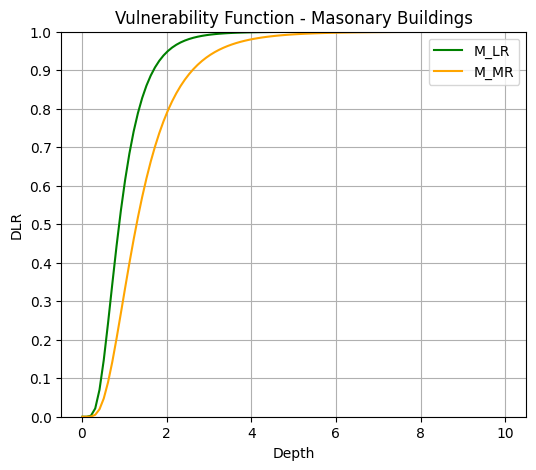

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Given parameters
mu = [1.0,1.5]  # mean
ln_sigma = [0.51,0.55]  # lognormal standard deviation
depth = np.linspace(0.01, 10, 100)
col = ['g', 'orange', 'r']
names = ['M_LR', 'M_MR']

# Plot the vulnerability functions
DI = np.zeros((len(names), len(depth)))
plt.figure(figsize=(6, 5))
for i in range(2):
    ln_mu = np.log(mu[i]) - 0.5 * ln_sigma[i] ** 2
    DI[i] = lognorm.cdf(depth, s=ln_sigma[i], scale=np.exp(ln_mu))
    plt.plot(depth, DI[i], label=names[i], color=col[i])
plt.xlabel('Depth')
plt.ylabel('DLR')
plt.title('Vulnerability Function - Masonary Buildings')
plt.legend()
plt.grid(True)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 11, 2))
plt.ylim([0, 1])
plt.show()

# Save the vulnerability functions
np.savetxt('Vul_M_LR.txt', np.column_stack((depth, DI[0])), delimiter=',', header='Depth, DLR_M_LR')
np.savetxt('Vul_M_MR.txt', np.column_stack((depth, DI[1])), delimiter=',', header='Depth, DLR_M_MR')


 Use the fragility functions for the RC structure from 2023 paper to derive the vulnerability functions using no uplift scenario(I):
 - RC_LR: 
    - slight damage(DS1) : median = 0.43, sigma = 0.18
    - moderate damage(DS2) : median = 0.73, sigma = 0.18
    - extensive damage(DS3) : median = 0.89, sigma = 0.17
    - complete damage(DS4) : median = .99, sigma = 0.14
- RC_MR: 
    - slight damage(DS1) : median = 0.57, sigma = 0.18
    - moderate damage(DS2) : median = 0.88, sigma = 0.20
    - extensive damage(DS3) : median = 1.05, sigma = 0.19
    - complete damage(DS4) : median = 1.18, sigma = 0.15
- RC_HR:
    - slight damage(DS1) : median = 0.72, sigma = 0.18
    - moderate damage(DS2) : median = 1.02, sigma = 0.21
    - extensive damage(DS3) : median = 1.19, sigma = 0.21
    - complete damage(DS4) : median = 1.31, sigma = 0.18

Assume damage states based on Italy spot report as follows:
DS1 = 10%, DS2 = 30%, DS3 = 60%, DS4 = 100%

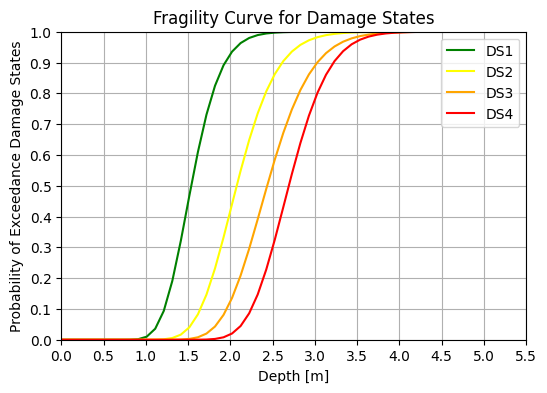

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


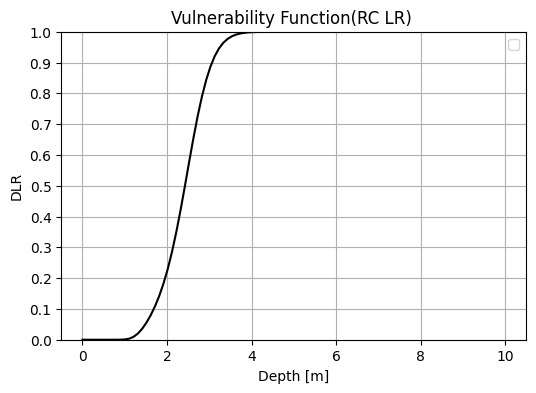

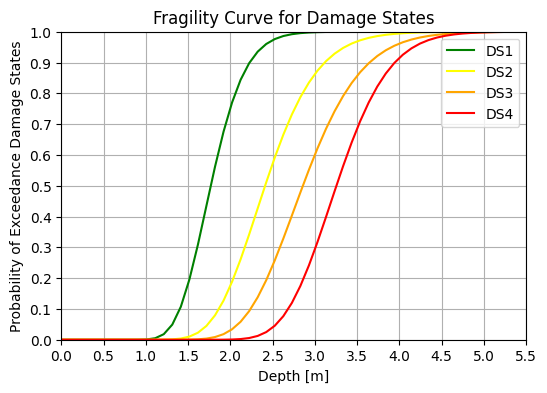

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


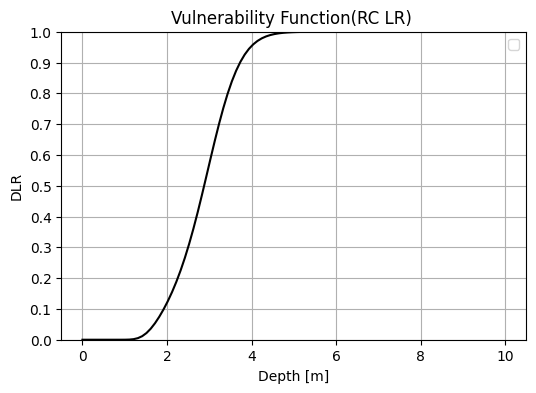

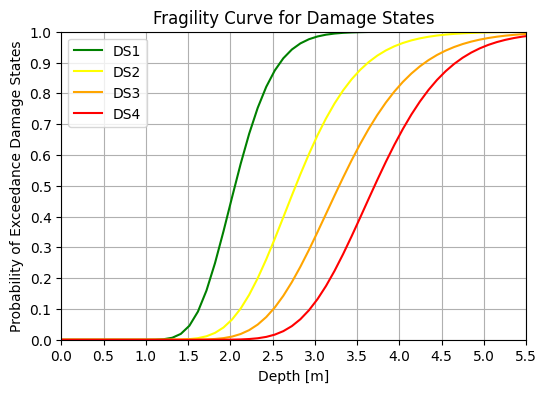

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


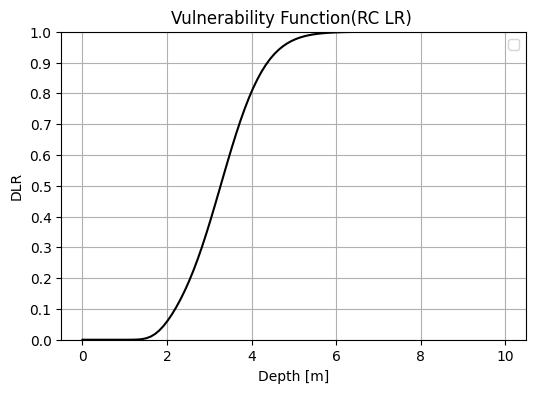

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

### define constants
median = [[0.43, 0.73, 0.89, 0.99],[0.57,0.88,1.05,1.18],[0.72,1.02,1.19,1.31]]
ln_sigma = [[0.18, 0.18, 0.17, 0.14],[0.18,0.20,0.19,0.15],[0.18,0.21,0.21,0.18]]
loss_ratio = [0.10, 0.30, 0.60, 1.00]
nDS = len(loss_ratio)
depths = np.linspace(0.00, 10, 100)
colors = ['green', 'yellow', 'orange', 'red']
names = ['DS1', 'DS2', 'DS3', 'DS4']
stories = ['LR', 'MR', 'HR']

def calculate_RC_fragility(depths, median, ln_sigma,loss_ratio, storytype = 'LR'):
        #calculate and plot the fragility functions using the lognormal distribution parameters
        pd_table = np.zeros((nDS, len(depths)))
        plt.figure(figsize=(6, 4))
        for i in range(nDS):
                pd_table[i]  = lognorm.cdf(depths, s=ln_sigma[i], scale=np.exp(median[i]))
                plt.plot(depths, pd_table[i] , label=names[i], color=colors[i])
        plt.xlabel('Depth [m]')
        plt.ylabel('Probability of Exceedance Damage States')
        plt.title('Fragility Curve for Damage States')
        plt.legend()
        plt.grid(True)
        plt.yticks(np.arange(0, 1.1, 0.1))
        plt.xticks(np.arange(0, 6, 0.5))
        plt.ylim([0, 1])
        plt.xlim([0, 5.5])
        plt.show()

        #Calculate the vulnerability function
        lossArray=np.zeros(len(depths))
        for i in range(len(depths)):
                for j in range(0,nDS):
                        if j==(nDS-1): #last damage state
                                lossArray[i] = lossArray[i] + pd_table[j,i]*loss_ratio[j] #probability of exceeding damage state j
                        else: #all other damage states
                                lossArray[i] = lossArray[i] + (pd_table[j,i]-pd_table[j+1,i])*loss_ratio[j] #probability of exceeding damage state j not exceeding damage state j+1                
        vulnCurve=np.column_stack((depths,lossArray))

        #plot the vulnerability function
        plt.figure(figsize=(6, 4))
        plt.plot(vulnCurve[:,0], vulnCurve[:,1], color = 'black')
        plt.xlabel('Depth [m]')
        plt.ylabel('DLR')
        plt.title('Vulnerability Function(RC LR) ')
        plt.legend()
        plt.grid(True)
        plt.yticks(np.arange(0, 1.1, 0.1))
        plt.xticks(np.arange(0, 11, 2))
        plt.ylim([0, 1])
        plt.show()
        # Save the vulnerability functions
        np.savetxt(f'Vul_RC_{storytype}.txt', vulnCurve, delimiter=',', header='Depth, DLR_RC_'+storytype)
        

calculate_RC_fragility(depths, median[0], ln_sigma[0],loss_ratio, storytype = 'LR')
calculate_RC_fragility(depths, median[1], ln_sigma[1],loss_ratio, storytype = 'MR')
calculate_RC_fragility(depths, median[2], ln_sigma[2],loss_ratio, storytype = 'HR')

Read and plot all vulnerability functions for checks.

['Vul_RC_LR.txt', 'Vul_RC_MR.txt', 'Vul_M_MR.txt', 'Vul_M_LR.txt', 'Vul_RC_HR.txt']


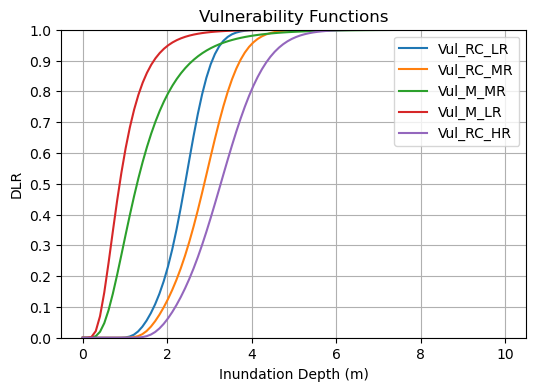

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

# list txt files in the current directory
txt_files = glob.glob('*.txt')
print(txt_files)

# plot the vulnerability functions
plt.figure(figsize=(6, 4))
for file in txt_files:
    data = np.loadtxt(file, delimiter=',', skiprows=1)
    plt.plot(data[:,0], data[:,1], label=file.split('.')[0])
plt.xlabel('Inundation Depth (m)')
plt.ylabel('DLR')
plt.title('Vulnerability Functions')
plt.legend()
plt.grid(True)
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xticks(np.arange(0, 11, 2))
plt.ylim([0, 1])
plt.show()

In [ ]:
for file in txt_files:
    data = np.loadtxt(file, delimiter=',', skiprows=1)
    data[:,0] = data[:,0]*100
    #set values less than 0.01 to 0
    # data[data[:,1]<0.001,1] = 0 #depth,lr,cov
    #add a zero or 1 filled column
    data = np.column_stack((data, np.zeros(len(data))))
    data = np.column_stack((data, np.ones(len(data))))
    #save values as rows in a csv file
    np.savetxt(f'{file}_row_cm.csv', data.T, delimiter=' ')

: 